In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import re

warnings.filterwarnings("ignore")

%matplotlib inline

## Reading the dataset

In [26]:
df=pd.read_csv("C:/Users/prath/Downloads/Churn Prediction/Data/data.csv")

## Exploring the data

In [27]:
rows=df.shape[0]
columns=df.shape[1]
print(f"Number of rows are {rows} and columns are {columns} in dataset")

Number of rows are 50000 and columns are 23 in dataset


In [28]:
print('Basic Descriptives of dataset')
df.describe()

Basic Descriptives of dataset


,annual_revenue_usd,contract_value_usd,tenure_months,product_usage_hours_3m,product_usage_hours_12m,login_frequency_30d,active_users,licensed_users,analyst_calls_6m,support_tickets_6m,support_escalations_6m,avg_resolution_time_hrs,nps_score,survey_response_count_12m,churn_flag
count,4.329300e+04,37265.000000,38426.000000,41870.000000,45525.000000,47172.000000,43536.000000,34551.000000,40008.000000,43422.000000,38485.000000,36498.000000,44607.000000,45071.000000,50000.000000
mean,1.780618e+05,89626.491643,29.945878,119.757052,520.213156,9.970846,5.990835,37.047553,1.508823,3.513565,0.598597,49.289553,-0.540857,1.189900,0.019640
std,4.209833e+05,45142.215930,29.678752,54.996010,180.040394,10.034615,2.459108,35.207416,1.229373,1.876507,0.774340,27.571193,58.127582,1.088492,0.138761
min,1.405019e+02,-101311.360200,0.000814,-109.987458,-182.053525,0.000032,0.000000,5.000000,0.000000,0.000000,0.000000,0.000732,-100.000000,0.000000,0.000000
25%,2.607467e+04,59516.694200,8.831021,82.676742,398.209222,2.883892,4.000000,10.000000,1.000000,2.000000,0.000000,28.082918,-51.000000,0.000000,0.000000
50%,6.636826e+04,89420.840080,20.906898,120.113561,520.095418,6.905612,6.000000,20.000000,1.000000,3.000000,0.000000,47.938245,-1.000000,1.000000,0.000000
75%,1.714133e+05,119800.787600,41.380318,156.962595,642.713605,13.689288,8.000000,50.000000,2.000000,5.000000,1.000000,68.375470,49.000000,2.000000,0.000000
max,2.459942e+07,264519.759500,349.137883,336.146419,1216.458645,104.641769,19.000000,100.000000,10.000000,13.000000,6.000000,170.639284,100.000000,8.000000,1.000000


####
* Median NPS score is -1 i.e. 50% of the accounts are not promoting Gartner to others. Maybe these accounts are not getting enough value from benchmarking products

* Median Login frequency for past 30 days is 6. Not many accounts have login in past one month

* Median Product usage hours in past 3 months is 120. This means a median client is using the product for 10 hours/week which is reasonable engagement(reading product landing pages,reviewing benchmark results,downloading collaterals attached on landing pages)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_id                  37285 non-null  object 
 1   industry                   43501 non-null  object 
 2   sub_industry               34321 non-null  object 
 3   region                     42481 non-null  object 
 4   company_size               39957 non-null  object 
 5   annual_revenue_usd         43293 non-null  float64
 6   contract_value_usd         37265 non-null  float64
 7   contract_length_months     39007 non-null  object 
 8   tenure_months              38426 non-null  float64
 9   product_usage_hours_3m     41870 non-null  float64
 10  product_usage_hours_12m    45525 non-null  float64
 11  login_frequency_30d        47172 non-null  float64
 12  active_users               43536 non-null  float64
 13  licensed_users             34551 non-null  flo

In [30]:
numerical_features=[feature for feature in df.columns if df[feature].dtype !="O"]
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']

print(f"There are {len(numerical_features)} numerical features and they are : {numerical_features}")
print(f"There are {len(categorical_features)} categorical features and they are : {categorical_features}")

There are 15 numerical features and they are : ['annual_revenue_usd', 'contract_value_usd', 'tenure_months', 'product_usage_hours_3m', 'product_usage_hours_12m', 'login_frequency_30d', 'active_users', 'licensed_users', 'analyst_calls_6m', 'support_tickets_6m', 'support_escalations_6m', 'avg_resolution_time_hrs', 'nps_score', 'survey_response_count_12m', 'churn_flag']
There are 8 categorical features and they are : ['client_id', 'industry', 'sub_industry', 'region', 'company_size', 'contract_length_months', 'discount_percent', 'account_notes']


## Data Cleaning/Data Pre-processing

###
Checking duplicates

In [31]:
duplicates=df.duplicated().sum()
print(f'Number of duplicates in the dataset : {duplicates}')

Number of duplicates in the dataset : 0


###
Dropping client_id since it is not important for analysis

In [32]:
df=df.drop(columns=['client_id'],axis=1)

In [33]:
df.columns

Index(['industry', 'sub_industry', 'region', 'company_size',
       'annual_revenue_usd', 'contract_value_usd', 'contract_length_months',
       'tenure_months', 'product_usage_hours_3m', 'product_usage_hours_12m',
       'login_frequency_30d', 'active_users', 'licensed_users',
       'analyst_calls_6m', 'support_tickets_6m', 'support_escalations_6m',
       'avg_resolution_time_hrs', 'nps_score', 'survey_response_count_12m',
       'discount_percent', 'account_notes', 'churn_flag'],
      dtype='object')

####
Standardizing the values in the columns. Replacing special characters and maintaining consistency.

In [34]:
def clean_industry(industry):
    
    if pd.isna(industry):
        return None
    industry=industry.lower()
    industry=re.sub(r"[^a-z\s]","a",industry)
    industry=industry.strip()

    mapping={
        "finanace":'Finance',
        'finance':'Finance',
        "retail":"Retail",
        'Heathcare':"Healthcare",
        'heathcare':"Healthcare",
        'manufacturing':"Manufacturing",
        'manufacturin':"Manufacturing",
        'TECH':"Technology",
        'technology':"Technology",
        'tech':"Technology",
        'saas':"Saas",
        'energy':"Energy"
    }
    return mapping.get(industry,industry.title())


def clean_region(region):
    
    if pd.isna(region):
        return None
    region=region.lower()
    region=re.sub(r"[^a-z\s]","a",region)
    region=region.strip()

    mapping={
        "north america":"North America",
        'n. america':"North America",
        'north americ':"North America",
        "na america":"North America",
        'latam':"Latam",
        'europe':"Europe",
        'middle east':"Middle East",
        'apac':"Apac"
    }
    return mapping.get(region,region.title())

def clean_sub_industry(sub_industry):
    if pd.isna(sub_industry):
        return None
    sub_industry=sub_industry.lower()
    sub_industry=re.sub(r'[^a-z\s]',"a",sub_industry)
    sub_industry=sub_industry.strip()

    mapping_sub_industry={
    'data':"Data",
    "ai":"AI",
    "cloud":"Cloud",
    "e-commerce":"E-commerce",
    "eacommerce":"E-commerce",
    "payments":"Payments",
    "cybersecurity":"Cybersecurity",
    'infra':"Infra"
    }
    return mapping_sub_industry.get(sub_industry,sub_industry.title())

def clean_contract_length_months(contract_length_months):
    if pd.isna(contract_length_months):
        return None
    mapping_month={
        "36 mnth":'36',
        "12 months":'12'
    }
    return mapping_month.get(contract_length_months,contract_length_months.title())

def clean_company_size(x):
    if pd.isna(x):
        return np.nan
    x=str(x).lower().strip()
    if 'k' in x:
        return int(float(x.replace('k',''))*1000)
    if '+' in x:
        return int(x.replace('+',''))
    return int(x)

In [35]:
df['industry']=df['industry'].apply(clean_industry)
df['region']=df['region'].apply(clean_region)
df['sub_industry']=df['sub_industry'].apply(clean_sub_industry)
df['contract_length_months']=df['contract_length_months'].apply(clean_contract_length_months)
df['company_size']=df['company_size'].apply(clean_company_size)

#### 
Renaming columns of the dataset to enhance readability

In [36]:
df.columns=df.columns.str.replace('_','')
new_column_names=['Industry', 'Sub Industry', 'Region', 'Company size',
       'Annual revenue(USD)', 'Contract value(USD)', 'Contract length(m)',
       'Tenure(m)', 'Product usage hours(3m)', 'Product usage hours(12m)', 'Login frequency(30d)',
       'Active users', 'Licensed users', 'Analyst calls(6m)', 'Support tickets(6m)',
       'Support escalations(6m)', 'Avg resolution time(hrs)', 'Nps score',
       'Survey response count(12m)', 'Discount', 'Account notes',
       'Churn flag']
df=df.set_axis(new_column_names,axis=1)

#### 
Since max of Tenure column is 350 therefore it is stored as months. We will convert tenure into days for better intutition

In [37]:
df['Tenure(d)']=round(df['Tenure(m)']*30,0)
df=df.drop(columns=['Tenure(m)'],axis=1)

####
Converting discount column to float and standardizing the values for better intuition

In [38]:
df['Discount']=df['Discount'].str.replace('%','',regex=True).astype(float)
df['Discount']=df['Discount']/100

#### 
Roudning off the values to 2 decimal places for better readability

In [39]:
cols_round_off=[
    'Annual revenue(USD)',
    'Contract value(USD)',
    'Product usage hours(3m)', 
    'Product usage hours(12m)',
    'Login frequency(30d)',
    'Avg resolution time(hrs)'
]
for col in cols_round_off:
    df[col]=pd.to_numeric(df[col],errors='coerce')

df[cols_round_off]=df[cols_round_off].round(2)

##### 
Challenge: 

Facing issue in changing data types of few columns. Upon investigating noticed that "int" dtype does not support NaN values hence it cannot convert a column that contains such values. After researching got to know that there is a nullable pandas integer dtype that is "Int64" specifically designed to handle integer values along with missing data.

Learning: 

Helped understanding the importance of handling missing values during type conversions. Would prefer using nullable dtypes or safe conversions during preprocessing to make pipelines more robust and avoid runtime errors.

In [40]:
df['Contract length(m)']=df['Contract length(m)'].astype("Int64")
df['Active users']=df['Active users'].astype('Int64')
df['Licensed users']=df['Licensed users'].astype("Int64")
df['Analyst calls(6m)']=df['Analyst calls(6m)'].astype("Int64")
df['Support escalations(6m)']=df['Support escalations(6m)'].astype("Int64")
df['Support tickets(6m)']=df['Support tickets(6m)'].astype("Int64")
df['Nps score']=df['Nps score'].astype("Int64")
df['Survey response count(12m)']=df['Survey response count(12m)'].astype("Int64")
df['Tenure(d)']=df['Tenure(d)'].astype("Int64")
df['Company size']=df['Company size'].astype("Int64")
df['Churn flag']=df['Churn flag'].astype('object')

## EDA(Exploratory Data Analysis)

#### 
What we have and why does it matter

* Contract signals - Contract value, Contract length → price sensitivity & commitment level
* Engagement signals - Product usage hours (3m & 12m), Login frequency, Active vs Licensed users → are they actually using what they pay for?
* Health signals - NPS score, Survey response count → voice of customer
* Risk signals - Support tickets, Support escalations, Avg resolution time → friction & frustration
* Relationship signals - Analyst calls, Discount, Tenure → stickiness & dependency
* Firmographic signals - Industry, Sub Industry, Region, Company size, Annual revenue → segmentation

#### Univariate Analysis

In [62]:
numerical_features=[feature for feature in df.columns if df[feature].dtype !="O"]
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']

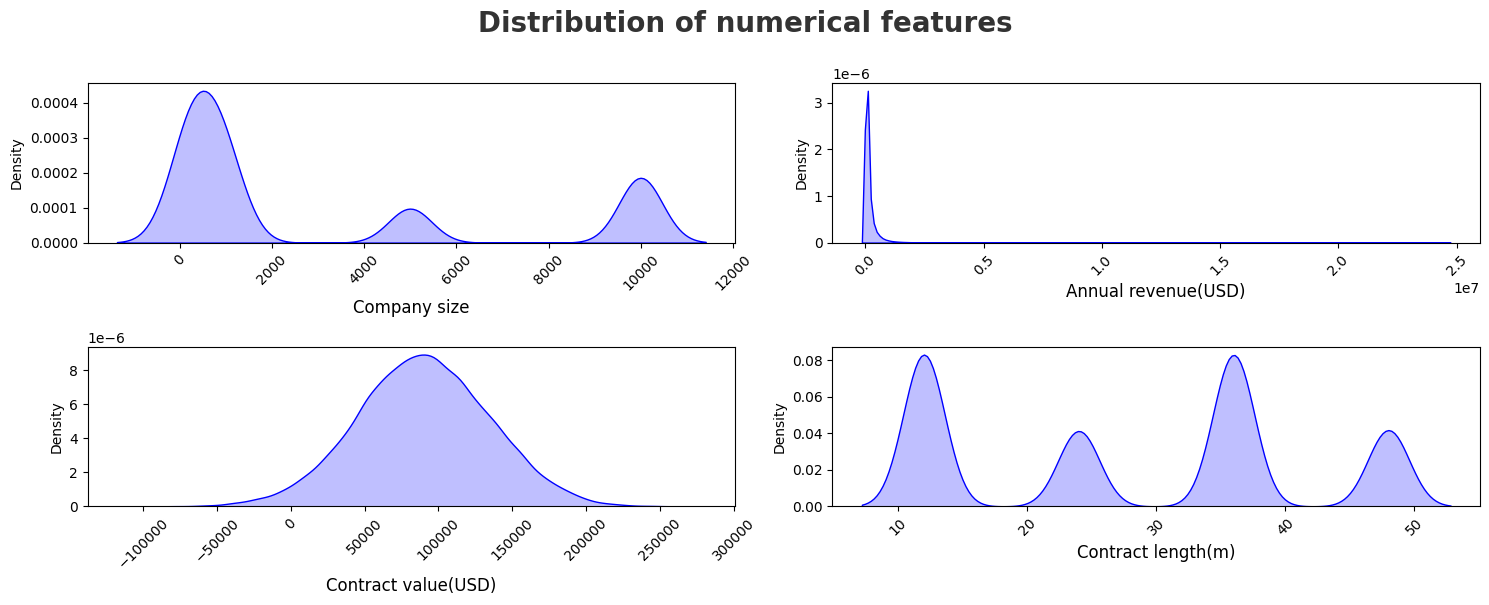

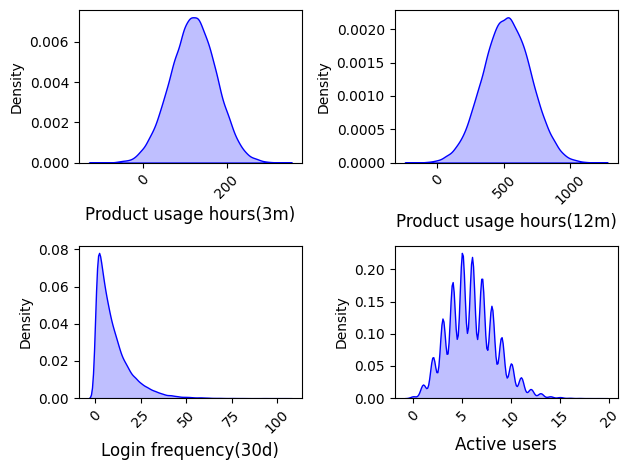

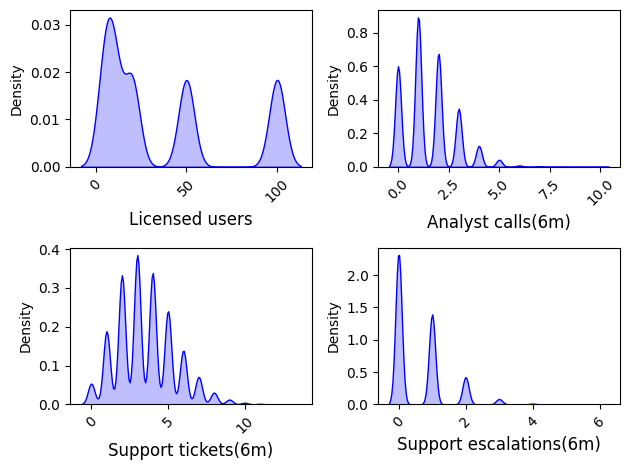

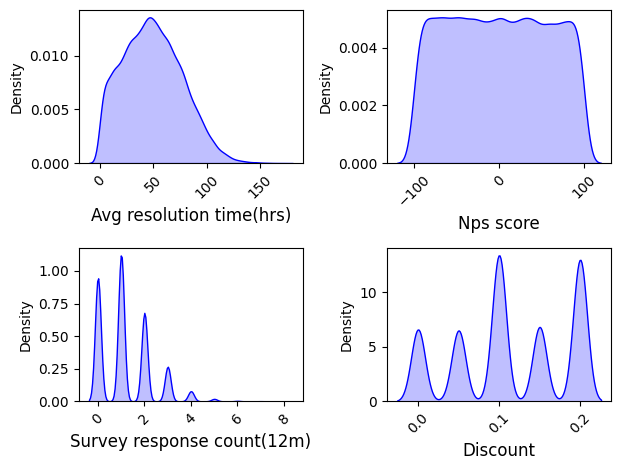

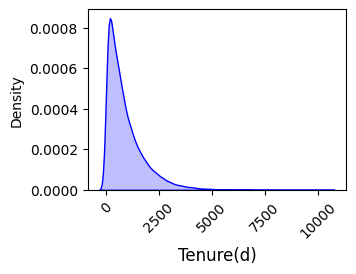

In [42]:
## Numerical features
plt.figure(figsize=(15,6))
plt.suptitle("Distribution of numerical features",fontsize=20,fontweight='bold',alpha=0.8,y=1.)
batch_size=4
for i in range(0,len(numerical_features),batch_size):
    subset=numerical_features[i:i+batch_size]
    for i,col in enumerate(subset):
        plt.subplot(2,2,i+1)
        sns.kdeplot(x=df[col],fill=True,color='blue')
        plt.xlabel(col,fontsize=12)
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

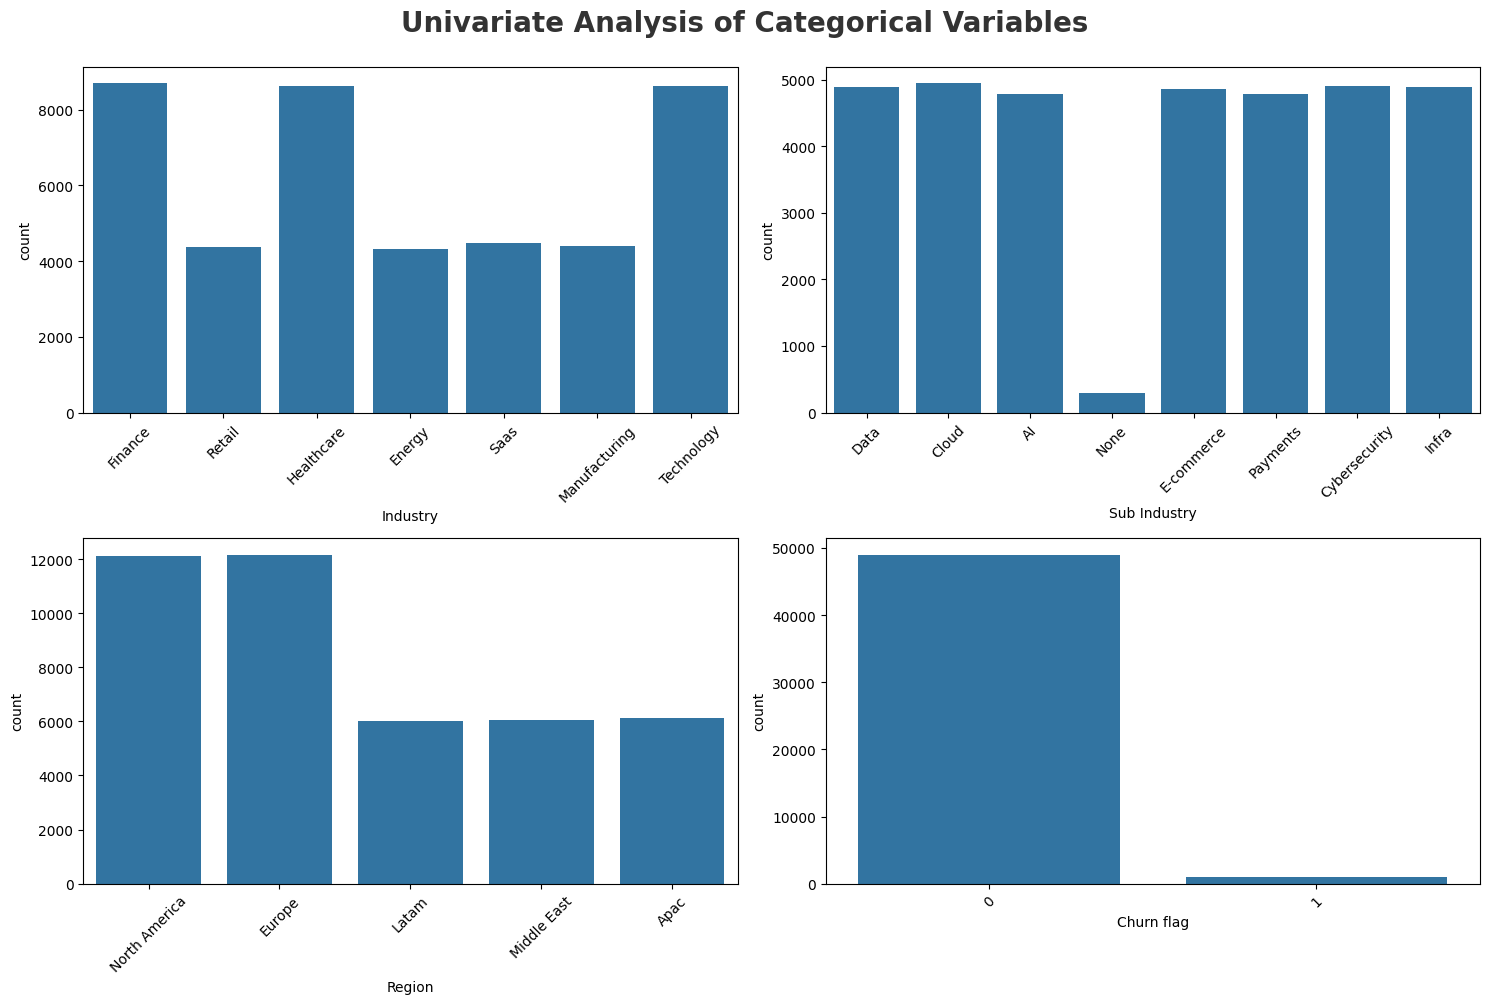

In [63]:
categories=['Industry','Sub Industry','Region','Churn flag']
fig,axes=plt.subplots(2,2,figsize=(15,10))
plt.suptitle('Univariate Analysis of Categorical Variables',fontsize=20,fontweight='bold',alpha=0.8,y=1.)
axes=axes.flatten()
for i,col in enumerate(categories):
    sns.countplot(data=df,x=col,ax=axes[i])
    # axes[i].set_title(col)
    axes[i].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()